When a protein binds to DNA, it protects the region it binds to from nucleases. We are given a data set with each entry being equivalent to the ordered pair: $(x, y)$, with $x$ being the position relative to the protein binding site and $y$ being the fragment length. We can visualize this as a heatmap where the $x$-axis represents the position relative to the binding site, the $y$-axis represents fragment lengths and the color intensity represents the count of fragments.

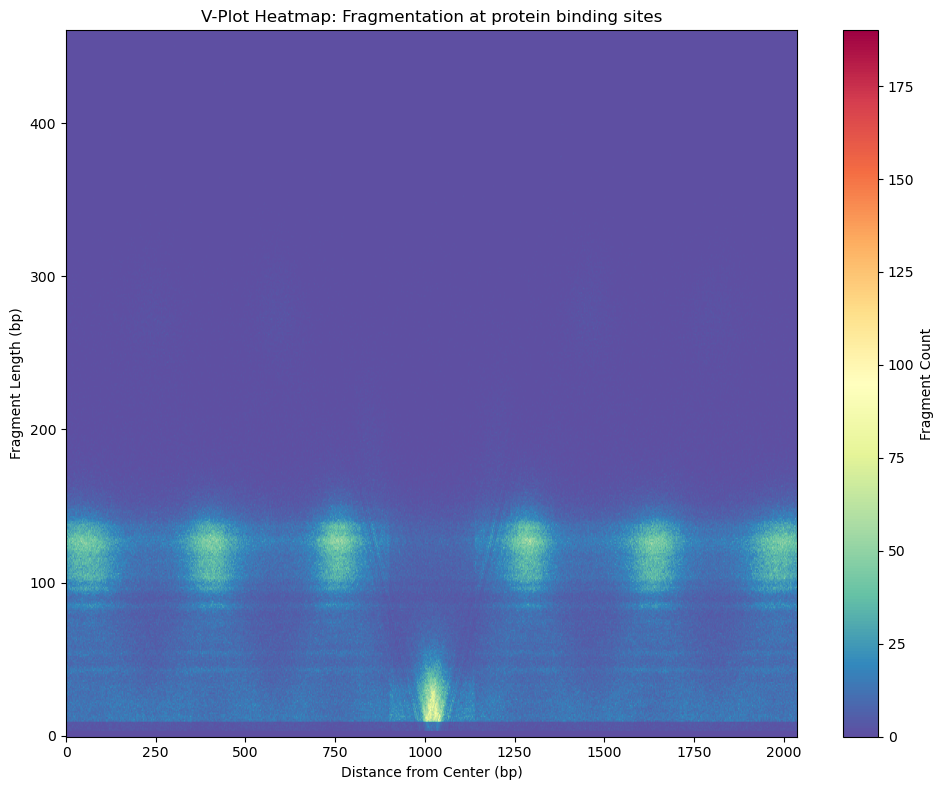

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/mapped.bed.gz', sep='\t', header=None, compression='gzip', usecols=[2,3,8,9])

# Using Pandas operations, we can easily calculate the row-wise operations that we need
df['C1'] = (df[2] + df[3]) / 2
df['C2'] = (df[8] + df[9]) / 2
df['X'] = df['C2'] - df['C1']
df['Y'] = df[9] - df[8]

# Aggregate counts (Z)
heatmap_df = df.groupby(['Y', 'X']).size().reset_index(name='Z')

# Pivot to matrix form
matrix = heatmap_df.pivot(index='Y', columns='X', values='Z').fillna(0)

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(matrix, aspect='auto', cmap='Spectral_r', origin='lower')
plt.xlabel('Distance from Center (bp)')
plt.ylabel('Fragment Length (bp)')
plt.title('V-Plot Heatmap: Fragmentation at protein binding sites')
plt.colorbar(label='Fragment Count')
plt.tight_layout()
plt.show()

This heatmap highlights the regions of high fragment density, revealing a **V-shaped** pattern around the binding site. We can conclude that the fragments found to be closer to the binding site tend to be shorter and longer fragments are further away as they can still overlap the binding site.